In [4]:
import os, sys
WORKDIR = "/data6/Users/choij/ChargedHiggsAnalysisV2/SignalRegionStudy"
sys.path.append(f"{WORKDIR}/python")

import numpy as np
import matplotlib.pyplot as plt

from sklearn.utils import shuffle
from sklearn.ensemble import GradientBoostingClassifier
import pickle, joblib

import ROOT

In [18]:
ERA = "2017"
CHANNEL = "SR1E2Mu"
MASSPOINT = "MHc-160_MA-85"
NFOLD = 5

In [19]:
# Get fitting results
result = ROOT.TFile.Open(f"{WORKDIR}/templates/{ERA}/{CHANNEL}/{MASSPOINT}/Shape/Baseline/fit_result.root").Get("fitresult_model_data")
mA = result.floatParsFinal().find("mA").getVal()
sigma = result.floatParsFinal().find("sigma").getVal()
width = result.floatParsFinal().find("width").getVal()
print(mA, sigma, width)
window = 7*np.sqrt(sigma**2 + width**2)
print(window)

84.85492280348329 0.7654854014195214 0.867617206143293
8.099237513058414


In [20]:
# Load dataset
def load_dataset(process):
    events = {}
    for i in range(NFOLD):
        events[i] = []
    f = ROOT.TFile(f"{WORKDIR}/samples/{ERA}/{CHANNEL.replace('SR', 'Skim')}/{MASSPOINT}/{process}.root")
    tree = f.Get(f"{process}_Central")
    for idx, evt in enumerate(tree, start=1):
        condition = (mA-window) < evt.mass1 < (mA+window) or (mA-window) < evt.mass2 < (mA+window)
        if not condition:
            continue
        events[evt.fold].append([evt.scoreX, evt.scoreY, evt.scoreZ, evt.weight, int(process == MASSPOINT)])
    return events

In [21]:
## training fold 0
## trainset = fold1, 2, 3, validset = fold 4, testset = fold 0
## First get all the events
events_sig = load_dataset(MASSPOINT)
events_bkg = {}
for i in range(NFOLD):
    events_bkg[i] = []

for bkg in ["WZ", "ZZ", "ttW", "ttZ", "ttH", "conversion", "nonprompt", "others"]:
    events_temp = load_dataset(bkg)
    for i in range(NFOLD):
        if events_bkg[i] is None:
            continue
        events_bkg[i].append(events_temp[i])
for i in range(NFOLD):
    events_sig[i] = np.array(events_sig[i])
    events_bkg[i] = np.concatenate(events_bkg[i], axis=0)   

In [22]:
# Scale background events, fold by fold
for i in range(NFOLD):
    ratio = np.sum(events_sig[i][:, 3])/np.sum(events_bkg[i][:, 3])
    events_bkg[i][:, 3] *= np.sum(events_sig[i][:, 3])/np.sum(events_bkg[i][:, 3])

In [23]:
# Make trainset
trainset = np.concatenate([events_sig[1], events_sig[2], events_sig[3], events_bkg[1], events_bkg[2], events_bkg[3]])
trainset = shuffle(trainset, random_state=42)
X_train, w_train, y_train = trainset[:, :3], trainset[:, 3], trainset[:, 4]

In [24]:
# testset
testset = np.concatenate([events_sig[0], events_bkg[0]])
testset = shuffle(testset, random_state=42)
X_test, w_test, y_test = testset[:, :3], testset[:, 3], testset[:, 4]

In [25]:
clf = GradientBoostingClassifier(n_estimators=30, max_depth=3, learning_rate=0.1, random_state=42)
clf.fit(X_train, y_train, sample_weight=w_train)
print(f"score X = {clf.feature_importances_[0]}")
print(f"score Y = {clf.feature_importances_[1]}")
print(f"score Z = {clf.feature_importances_[2]}")

score X = 0.08454669522248924
score Y = 0.36766862237770603
score Z = 0.5477846823998047


In [26]:
hSigTrain = ROOT.TH1D("hSigTrain", "hSigTrain", 100, 0., 1.)
hBkgTrain = ROOT.TH1D("hBkgTrain", "hBkgTrain", 100, 0., 1.)
hSigTest = ROOT.TH1D("hSigTest", "hSigTest", 100, 0., 1.)
hBkgTest = ROOT.TH1D("hBkgTest", "hBkgTest", 100, 0., 1.)

y_pred = clf.predict_proba(X_train)
for score, weight, label in zip(y_pred, w_train, y_train):
    if label == 1:
        hSigTrain.Fill(score[1], weight)
    else:
        hBkgTrain.Fill(score[1], weight)
        
y_pred = clf.predict_proba(X_test)
for score, weight, label in zip(y_pred, w_test, y_test):
    if label == 1:
        hSigTest.Fill(score[1], weight)
    else:
        hBkgTest.Fill(score[1], weight)

Warning in <TROOT::Append>: Replacing existing TH1: hSigTrain (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: hBkgTrain (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: hSigTest (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: hBkgTest (Potential memory leak).


In [27]:
ksProbSig = hSigTrain.KolmogorovTest(hSigTest, option="X")
ksProbBkg = hBkgTrain.KolmogorovTest(hBkgTest, option="X")
print(f"@@@@ ksProbSig = {ksProbSig}")
print(f"@@@@ ksProbBkg = {ksProbBkg}")

@@@@ ksProbSig = 0.0
@@@@ ksProbBkg = 0.253


Warning in <TH1D::KolmogorovTest>: Detected bins with negative weights, these have been ignored and output might be skewed. Reduce number of bins for histogram?


In [28]:
print("@@@@ save results...")
hSigTrain.SetLineColor(ROOT.kBlack)
hBkgTrain.SetLineColor(ROOT.kBlue)
hSigTrain.SetLineWidth(2)
hBkgTrain.SetLineWidth(2)
hSigTest.SetMarkerStyle(20)
hBkgTest.SetMarkerStyle(20)
hSigTest.SetMarkerSize(1)
hBkgTest.SetMarkerSize(1)
hSigTest.SetMarkerColor(ROOT.kBlack)
hBkgTest.SetMarkerColor(ROOT.kBlue)
hSigTrain.SetStats(0)
hBkgTrain.SetStats(0)

hSigTrain.Scale(1./hSigTrain.Integral())
hBkgTrain.Scale(1./hBkgTrain.Integral())
hSigTest.Scale(1./hSigTest.Integral())
hBkgTest.Scale(1./hBkgTest.Integral())
yMax = max(hSigTrain.GetMaximum(), hBkgTrain.GetMaximum())
hSigTrain.GetYaxis().SetRangeUser(0., yMax*1.6)
hSigTrain.SetTitle("Gradient Boosting Classifier")
hSigTrain.GetXaxis().SetTitle("score")
hSigTrain.GetYaxis().SetTitle("events")
latex = ROOT.TLatex()
    
c = ROOT.TCanvas()
c.cd()
hSigTrain.Draw("hist")
hBkgTrain.Draw("hist&same")
hSigTest.Draw("p&same")
hBkgTest.Draw("p&same")
latex.DrawLatexNDC(0.6, 0.83, f"n_estimator = {10}")
latex.DrawLatexNDC(0.6, 0.78, "max_depth = 3")
latex.DrawLatexNDC(0.2, 0.85, f"mass window = 5*"+"#sigma_{A}")
latex.DrawLatexNDC(0.2, 0.8, f"ks score (sig) = {ksProbSig}")
latex.DrawLatexNDC(0.2, 0.75, f"ks score (bkg) = {ksProbBkg}")

@@@@ save results...


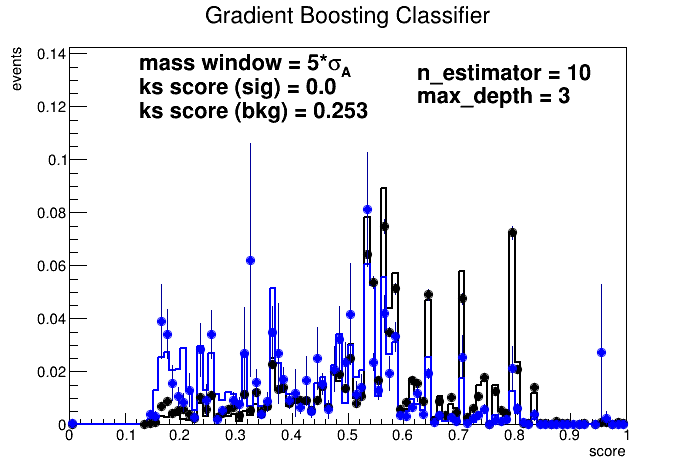

In [29]:
c.Draw()

@@@@ initMetric = 1.655
@@@@ bestMetric = 1.702
@@@@ improvement = 2.82%
@@@@ best cut = 0.33


Warning in <TROOT::Append>: Replacing existing TH1: hSig (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: hBkg (Potential memory leak).


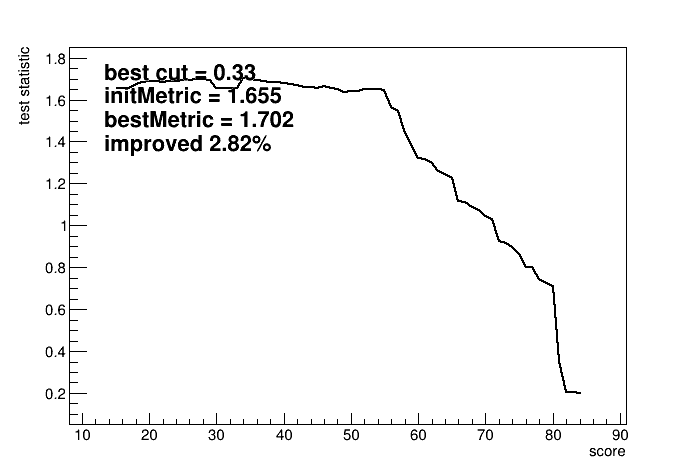

In [31]:
# Optimization
hSig = ROOT.TH1D("hSig", "", 100, 0., 1.)
hBkg = ROOT.TH1D("hBkg", "", 100, 0., 1.)
y_pred = clf.predict_proba(X_test)
for score, weight, label in zip(y_pred, w_test, y_test):
    if label == 1:
        hSig.Fill(score[1], weight)
    else:
        hBkg.Fill(score[1], weight)

nBins = hSig.GetNbinsX()
nSig = hSig.Integral(0, nBins+1)
nBkg = hBkg.Integral(0, nBins+1)
initMetric = np.sqrt(2*((nSig+nBkg)*np.log(1+nSig/nBkg)-nSig))
graph = ROOT.TGraph()
bestCut = 0
bestMetric = initMetric
for bin in range(15, nBins-15):
    nSig = hSig.Integral(bin, nBins+1)
    nBkg = hBkg.Integral(bin, nBins+1)
    try:
        metric = np.sqrt(2*((nSig+nBkg)*np.log(1+nSig/nBkg)-nSig))
        graph.AddPoint(bin, metric)
    except:
        print(bin, nSig, nBkg)
        continue
    if metric > bestMetric:
        bestCut = bin
        bestMetric = metric
bestCut = hSig.GetXaxis().GetBinLowEdge(bestCut)
improvement = (bestMetric-initMetric) / initMetric
print(f"@@@@ initMetric = {initMetric:.3f}")
print(f"@@@@ bestMetric = {bestMetric:.3f}")
print(f"@@@@ improvement = {improvement*100:.2f}%")
print(f"@@@@ best cut = {bestCut:.2f}")

graph.SetLineColor(ROOT.kBlack)
graph.SetLineWidth(2)
graph.GetXaxis().SetTitle("score")
graph.GetYaxis().SetTitle("test statistic")
latex = ROOT.TLatex()
c = ROOT.TCanvas()
c.cd()
graph.Draw()
latex.DrawLatexNDC(0.15, 0.83, f"best cut = {bestCut:.2f}")
latex.DrawLatexNDC(0.15, 0.78, f"initMetric = {initMetric:.3f}")
latex.DrawLatexNDC(0.15, 0.73, f"bestMetric = {bestMetric:.3f}")
latex.DrawLatexNDC(0.15, 0.68, f"improved {improvement*100:.2f}%")
c.Draw()